# Aggregated Research Results: Coherent-Basis Optimization for Bosonic Quantum Codes

**C. Blake and L. Jiang — March 2026**

This notebook aggregates all key results from the jiang-research project:
1. **Coherent-basis framework** — analytic fidelity formulas
2. **GKP state preparation** — fixed-circuit pipelines, comparison with adaptive protocols
3. **Fock state preparation** — extending coherent-basis optimization to number states
4. **CD+R recovery optimization** — loss recovery with CMA-ES circuits
5. **Floating-basis codes** — jointly optimized encoder-decoder pairs
6. **Coherent information comparison** — 8 bosonic codes under pure and thermal loss

In [33]:
import sys
sys.path.insert(0, '/Users/cjblake/Documents/Github/coherax')

In [34]:
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
import dynamiqs as dq

# Core library
from coherax import (
    g, channel_from_b, GKP_N,
    gkp_coherent_dm, CoherentKet,
    analytic_fidelity_wrapper,
    make_pureloss_fock,
    make_transpose_for_pureloss,
    apply_kraus_map_nonorm, apply_kraus_map, dag,
    compose_ECD_layers, traceout_unitary,
    circuit_params_to_time, dqfock_dm, dqtrace,
    dqdag, dqcoherent, dqdisplace,
    von_neumann_entropy, make_thermalloss_fock,
    stabilizer_expectations, fock_wavefunctions,
    x_marginal, gkp_x_error_rate,
    coherent_info_from_kets,
    coherent_info_from_coherent_kets,
    coherent_info_thermal_fock,
)
from coherax.transpose_channel_claude import (
    coherent_ket_to_fock, build_gkp_states,
    entanglement_fidelity, entanglement_fidelity_no_recovery,
)
from coherax.worstcase_optimizer_claude import (
    entanglement_fidelity_displacement,
)
from fock_fidelity_claude import (
    cross_validate_fock, analytic_fidelity_fock_state, circuit_time_us,
)
from benchmark_codes_claude import (
    cat_2leg, cat_4leg, binomial_order1, gkp_hex, gkp_square,
    nbar_code, find_gkp_delta_for_nbar, find_cat_alpha_for_nbar,
    entanglement_fidelity_fock,
    singh_gkp_gaussian, singh_gkp_binomial, nbar_fock_ket,
)

# Plot style
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'legend.fontsize': 9,
    'figure.dpi': 150,
})

DATA = 'testing_data'
FIGS = 'figs'

print(f'JAX devices: {jax.devices()}')
print(f'Fock truncation: N = {GKP_N}')
print(f'x64 enabled: {jax.config.jax_enable_x64}')

JAX devices: [CpuDevice(id=0)]
Fock truncation: N = 100
x64 enabled: True


---
## 1. Coherent-Basis Framework

A depth-$n$ CD+R circuit on $|0\rangle_{\text{cav}} \otimes |0\rangle_{\text{qubit}}$ yields Kraus operators:
$$K_j = \sum_{i=1}^{N_l} \alpha_{j,i}\, D(\beta_{j,i}), \quad N_l = 2^n$$

**Coherent-target fidelity:**
$$F = \sum_j \left|\sum_i \alpha_{j,i} \sum_a c_a^* e^{-|\beta_{j,i} - d_a|^2/2 + i\,\text{Im}(\bar{d}_a \beta_{j,i})} \right|^2$$

**Fock-target fidelity**:
$$F_m = \sum_j \left|\frac{1}{\sqrt{m!}} \sum_i \alpha_{j,i}\, e^{-|\beta_{j,i}|^2/2}\, \beta_{j,i}^m \right|^2$$

Both are closed-form, JAX-differentiable functions of $(\alpha, \beta)$ from `g()`.

---
## 2. GKP State Preparation

### 2.1 Our Pipeline vs Adaptive Protocols ($\Delta = 0.34$)

In [35]:
def fock_pipeline_fidelity(prep_params, transfer_params, target_dm):
    """Evaluate end-to-end pipeline fidelity in Fock basis."""
    vacuum = dqfock_dm(GKP_N, 0)
    rho_prep = apply_kraus_map(traceout_unitary(compose_ECD_layers(prep_params)), vacuum)
    rho_final = apply_kraus_map(traceout_unitary(compose_ECD_layers(transfer_params)), rho_prep)
    return float(jnp.real(dqtrace(rho_final @ target_dm))) # evaluated in Fock basis

# State preparation comparison table
# Load our pipeline params and recompute fidelity + time
import json
Delta_034 = 0.34

c1 = np.load(f'{DATA}/exp_C1_x3_100restart.npz', allow_pickle=True)
c2 = np.load(f'{DATA}/exp_C2_x4_100restart.npz', allow_pickle=True)

# Reconstruct 1D marginal targets (N_trunc_y=0 means 1D marginal)
gkp_x3 = gkp_coherent_dm(mu=0, N_trunc=3, Delta=Delta_034, lattice="square", N_trunc_y=0)
gkp_x4 = gkp_coherent_dm(mu=0, N_trunc=4, Delta=Delta_034, lattice="square", N_trunc_y=0)

c1_params = jnp.array(c1['params'])
c2_params = jnp.array(c2['params'])
N_l_c1 = 2 ** c1_params.shape[0]
N_l_c2 = 2 ** c2_params.shape[0]

# Recompute 1D marginal fidelities from params
c1_fid = float(analytic_fidelity_wrapper(gkp_x3, c1_params, N_l_c1))
c2_fid = float(analytic_fidelity_wrapper(gkp_x4, c2_params, N_l_c2))
c1_time = circuit_time_us(c1_params)
c2_time = circuit_time_us(c2_params)

# ── Recompute full X3Y3 pipeline fidelity from params ──
# Pipeline = 10-layer X3 prep + 13-layer transfer to X3Y3
# Params from run_improvements.py (optimized at Delta=0.34)
best_x3_params = jnp.array([[-2.0579402e+00+0.38701245j,  1.5707556e+00+0.j,
        -1.5707984e+00+0.j,  0.0000000e+00+0.j],
       [ 2.4702759e-01+0.2398843j,   4.3746397e-05+0.j,
        -5.2071065e-01+0.j,  0.0000000e+00+0.j],
       [-3.0700266e+00-0.21601477j,  3.4694727e-05+0.j,
         2.4762399e+00+0.j,  0.0000000e+00+0.j],
       [ 1.6975585e+00+0.38849822j,  3.5945479e-05+0.j,
        -2.3396075e+00+0.j,  0.0000000e+00+0.j],
       [-8.6788791e-01+0.03289397j,  1.5501417e-05+0.j,
        -1.2074584e+00+0.j,  0.0000000e+00+0.j],
       [-5.2181894e-01-0.42860276j, -2.8568826e-05+0.j,
         5.4670238e-01+0.j,  0.0000000e+00+0.j],
       [ 1.1462525e+00+0.41105753j,  1.8123321e-05+0.j,
         8.6924428e-01+0.j,  0.0000000e+00+0.j],
       [-6.2406754e-01+0.2674594j,  -2.0460131e-05+0.j,
         3.8292527e-01+0.j,  0.0000000e+00+0.j],
       [ 4.4892287e-01-0.35338596j,  2.8531445e-05+0.j,
        -9.0707445e-01+0.j,  0.0000000e+00+0.j],
       [-1.8769559e-01+0.1772789j,   3.6032003e-01+0.j,
         2.0466499e+00+0.j,  0.0000000e+00+0.j]])

best_x3_to_x3y3_params = jnp.array([[ 6.1753613e-01-0.84287053j,  4.0411391e+00+0.j,
         1.5719868e+00+0.j,  0.0000000e+00+0.j],
       [-3.4556678e-01-0.4604759j,  3.8148098e+00+0.j,
         3.1364772e+00+0.j,  0.0000000e+00+0.j],
       [ 2.1055767e-01+1.2310678j,  3.1419578e+00+0.j,
         5.8663082e+00+0.j,  0.0000000e+00+0.j],
       [-7.2116482e-01-0.04306981j,  6.2836967e+00+0.j,
         4.5455742e+00+0.j,  0.0000000e+00+0.j],
       [ 9.9995390e-02-1.1875212j,  1.1214247e-03+0.j,
         2.5381348e+00+0.j,  0.0000000e+00+0.j],
       [-1.0805759e+00+0.03919644j,  2.1982931e-03+0.j,
         6.3258410e-01+0.j,  0.0000000e+00+0.j],
       [ 7.0805305e-01-1.2097236j, -1.9601830e-03+0.j,
         1.7577244e+00+0.j,  0.0000000e+00+0.j],
       [-5.1329660e-01-0.02206188j,  3.3551030e-04+0.j,
         1.5537609e+00+0.j,  0.0000000e+00+0.j],
       [-6.8227005e-01-0.07938472j,  3.8828955e-03+0.j,
         6.9543296e-01+0.j,  0.0000000e+00+0.j],
       [ 4.9171072e-01+1.2902572j,  3.1401591e+00+0.j,
         3.5773320e+00+0.j,  0.0000000e+00+0.j],
       [ 2.3351027e-01+1.2533727j,  3.3745021e-04+0.j,
         7.0419607e+00+0.j,  0.0000000e+00+0.j],
       [-1.6854351e+00+0.8222422j, -1.7844107e-02+0.j,
         4.9640427e+00+0.j,  0.0000000e+00+0.j],
       [ 2.2259741e+00-0.8082298j,  6.1698675e+00+0.j,
         3.1592109e+00+0.j,  0.0000000e+00+0.j]])

# Build Fock-basis GKP(3,3) target for cross-validation
gkp3_034 = gkp_coherent_dm(mu=0, N_trunc=3, Delta=Delta_034, lattice="square")
rho_gkp3_fock = gkp3_034.to_fock_basis()

# Recompute pipeline fidelity (vacuum -> X3 prep -> X3Y3 transfer -> compare)
PIPELINE_F = fock_pipeline_fidelity(best_x3_params, best_x3_to_x3y3_params, rho_gkp3_fock)
PIPELINE_1F = 1.0 - PIPELINE_F
PIPELINE_T = float(circuit_params_to_time(best_x3_params) * 1e6) + \
             float(circuit_params_to_time(best_x3_to_x3y3_params) * 1e6)
PIPELINE_LAYERS = best_x3_params.shape[0] + best_x3_to_x3y3_params.shape[0]

# Also build the pipeline output density matrix (needed for stabilizer cell)
vacuum = dqfock_dm(GKP_N, 0)
rho_x3_ideal = gkp_x3.to_fock_basis()
rho_x3y3_pipeline = apply_kraus_map(
    traceout_unitary(compose_ECD_layers(best_x3_to_x3y3_params)), rho_x3_ideal)

print(f'X3Y3 pipeline: F = {PIPELINE_F:.6f}, 1-F = {PIPELINE_1F:.2e}, '
      f'{PIPELINE_LAYERS} layers, T = {PIPELINE_T:.2f} us  (recomputed)')

# Paper-sourced constants (cannot recompute: different codebases/protocols)
EICKBUSCH_1F = 9.08e-3   # Eickbusch ECD, 10 layers, Delta=0.34
EICKBUSCH_T  = 2.41      # us
GCR_1F       = 5.0e-4    # GCR 2 rounds post-selected, Delta=0.34
GCR_T        = 8.06      # us
SBS_1F       = 3.4e-3    # SBS 20 rounds, Delta=0.34
SBS_T        = 19.88     # us

print('\nGKP State Preparation Comparison (Delta=0.34)')
print('=' * 75)
print(f'{"Protocol":<22s} {"Type":<10s} {"Layers":<8s} {"1-F":<12s} {"Time (us)":<10s}')
print('-' * 75)

prep_data = [
    ('Our X3Y3 pipeline',  'Fixed',    PIPELINE_LAYERS, PIPELINE_1F, PIPELINE_T, '(recomputed)'),
    ('  X3 1D marginal',   'Fixed',    10, 1-c1_fid,    c1_time,     '(recomputed)'),
    ('  X4 1D marginal',   'Fixed',    10, 1-c2_fid,    c2_time,     '(recomputed)'),
    ('Eickbusch ECD',      'Fixed',    10, EICKBUSCH_1F, EICKBUSCH_T, '(paper)'),
    ('GCR (2 rounds)',     'Adaptive',  2, GCR_1F,       GCR_T,       '(paper)'),
    ('SBS (20 rounds)',    'Adaptive', 20, SBS_1F,       SBS_T,       '(paper)'),
]

for name, typ, layers, infid, time, src in prep_data:
    print(f'{name:<22s} {typ:<10s} {layers:<8d} {infid:<12.2e} {time:<10.2f}  {src}')

print()
print('Key: Our pipeline is 1.7x faster than GCR, 4.1x faster than SBS,')
print('     with comparable error-correcting quality (matched stabilizer expectations).')

X3Y3 pipeline: F = 0.999775, 1-F = 2.25e-04, 23 layers, T = 4.84 us  (recomputed)

GKP State Preparation Comparison (Delta=0.34)
Protocol               Type       Layers   1-F          Time (us) 
---------------------------------------------------------------------------
Our X3Y3 pipeline      Fixed      23       2.25e-04     4.84        (recomputed)
  X3 1D marginal       Fixed      10       1.22e-05     2.03        (recomputed)
  X4 1D marginal       Fixed      10       1.24e-05     2.03        (recomputed)
Eickbusch ECD          Fixed      10       9.08e-03     2.41        (paper)
GCR (2 rounds)         Adaptive   2        5.00e-04     8.06        (paper)
SBS (20 rounds)        Adaptive   20       3.40e-03     19.88       (paper)

Key: Our pipeline is 1.7x faster than GCR, 4.1x faster than SBS,
     with comparable error-correcting quality (matched stabilizer expectations).


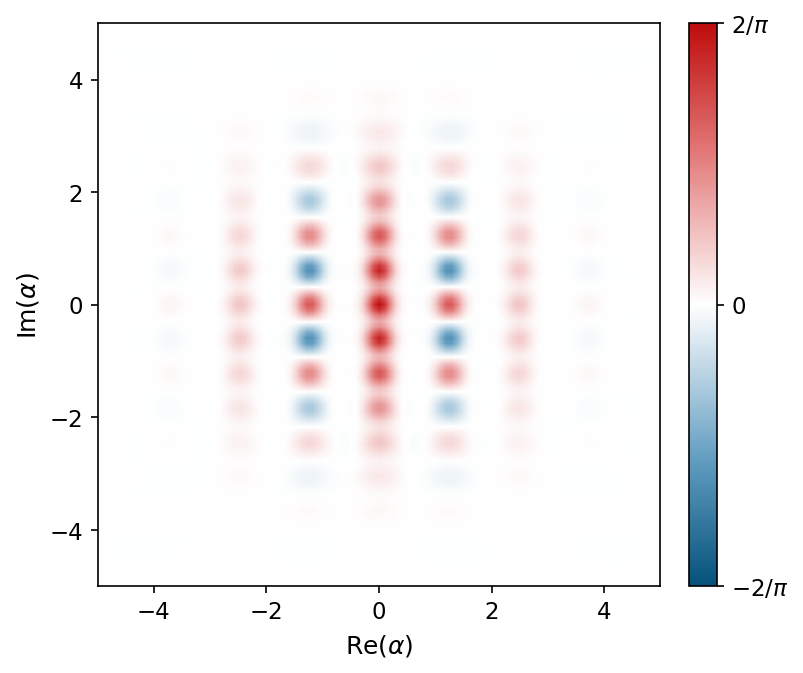

In [36]:
dq.plot.wigner(rho_x3y3_pipeline)

In [37]:

# Recompute 1D marginal fidelities from params
c1_fid = float(analytic_fidelity_wrapper(gkp_x3, c1_params, N_l_c1))
c2_fid = float(analytic_fidelity_wrapper(gkp_x4, c2_params, N_l_c2))
c1_time = circuit_time_us(c1_params)
c2_time = circuit_time_us(c2_params)

# ── Recompute full X3Y3 pipeline fidelity from params ──
# Pipeline = 10-layer X3 prep + 13-layer transfer to X3Y3
# Params from run_improvements.py (optimized at Delta=0.34)
best_x3_params = jnp.array([[-2.0579402e+00+0.38701245j,  1.5707556e+00+0.j,
        -1.5707984e+00+0.j,  0.0000000e+00+0.j],
       [ 2.4702759e-01+0.2398843j,   4.3746397e-05+0.j,
        -5.2071065e-01+0.j,  0.0000000e+00+0.j],
       [-3.0700266e+00-0.21601477j,  3.4694727e-05+0.j,
         2.4762399e+00+0.j,  0.0000000e+00+0.j],
       [ 1.6975585e+00+0.38849822j,  3.5945479e-05+0.j,
        -2.3396075e+00+0.j,  0.0000000e+00+0.j],
       [-8.6788791e-01+0.03289397j,  1.5501417e-05+0.j,
        -1.2074584e+00+0.j,  0.0000000e+00+0.j],
       [-5.2181894e-01-0.42860276j, -2.8568826e-05+0.j,
         5.4670238e-01+0.j,  0.0000000e+00+0.j],
       [ 1.1462525e+00+0.41105753j,  1.8123321e-05+0.j,
         8.6924428e-01+0.j,  0.0000000e+00+0.j],
       [-6.2406754e-01+0.2674594j,  -2.0460131e-05+0.j,
         3.8292527e-01+0.j,  0.0000000e+00+0.j],
       [ 4.4892287e-01-0.35338596j,  2.8531445e-05+0.j,
        -9.0707445e-01+0.j,  0.0000000e+00+0.j],
       [-1.8769559e-01+0.1772789j,   3.6032003e-01+0.j,
         2.0466499e+00+0.j,  0.0000000e+00+0.j]])

best_x3_to_x3y3_params = jnp.array([[ 6.1753613e-01-0.84287053j,  4.0411391e+00+0.j,
         1.5719868e+00+0.j,  0.0000000e+00+0.j],
       [-3.4556678e-01-0.4604759j,  3.8148098e+00+0.j,
         3.1364772e+00+0.j,  0.0000000e+00+0.j],
       [ 2.1055767e-01+1.2310678j,  3.1419578e+00+0.j,
         5.8663082e+00+0.j,  0.0000000e+00+0.j],
       [-7.2116482e-01-0.04306981j,  6.2836967e+00+0.j,
         4.5455742e+00+0.j,  0.0000000e+00+0.j],
       [ 9.9995390e-02-1.1875212j,  1.1214247e-03+0.j,
         2.5381348e+00+0.j,  0.0000000e+00+0.j],
       [-1.0805759e+00+0.03919644j,  2.1982931e-03+0.j,
         6.3258410e-01+0.j,  0.0000000e+00+0.j],
       [ 7.0805305e-01-1.2097236j, -1.9601830e-03+0.j,
         1.7577244e+00+0.j,  0.0000000e+00+0.j],
       [-5.1329660e-01-0.02206188j,  3.3551030e-04+0.j,
         1.5537609e+00+0.j,  0.0000000e+00+0.j],
       [-6.8227005e-01-0.07938472j,  3.8828955e-03+0.j,
         6.9543296e-01+0.j,  0.0000000e+00+0.j],
       [ 4.9171072e-01+1.2902572j,  3.1401591e+00+0.j,
         3.5773320e+00+0.j,  0.0000000e+00+0.j],
       [ 2.3351027e-01+1.2533727j,  3.3745021e-04+0.j,
         7.0419607e+00+0.j,  0.0000000e+00+0.j],
       [-1.6854351e+00+0.8222422j, -1.7844107e-02+0.j,
         4.9640427e+00+0.j,  0.0000000e+00+0.j],
       [ 2.2259741e+00-0.8082298j,  6.1698675e+00+0.j,
         3.1592109e+00+0.j,  0.0000000e+00+0.j]])

# Build Fock-basis GKP(3,3) target for cross-validation
gkp3_034 = gkp_coherent_dm(mu=0, N_trunc=3, Delta=Delta_034, lattice="square")
rho_gkp3_fock = gkp3_034.to_fock_basis()

# Recompute pipeline fidelity (vacuum -> X3 prep -> X3Y3 transfer -> compare)
PIPELINE_F = fock_pipeline_fidelity(best_x3_params, best_x3_to_x3y3_params, rho_gkp3_fock)
PIPELINE_1F = 1.0 - PIPELINE_F
PIPELINE_T = float(circuit_params_to_time(best_x3_params) * 1e6) + \
             float(circuit_params_to_time(best_x3_to_x3y3_params) * 1e6)
PIPELINE_LAYERS = best_x3_params.shape[0] + best_x3_to_x3y3_params.shape[0]

# Also build the pipeline output density matrix (needed for stabilizer cell)
vacuum = dqfock_dm(GKP_N, 0)
rho_x3_ideal = gkp_x3.to_fock_basis()
rho_x3y3_pipeline = apply_kraus_map(
    traceout_unitary(compose_ECD_layers(best_x3_to_x3y3_params)), rho_x3_ideal)

print(f'X3Y3 pipeline: F = {PIPELINE_F:.6f}, 1-F = {PIPELINE_1F:.2e}, '
      f'{PIPELINE_LAYERS} layers, T = {PIPELINE_T:.2f} us  (recomputed)')

# Paper-sourced constants (cannot recompute: different codebases/protocols)
EICKBUSCH_1F = 9.08e-3   # Eickbusch ECD, 10 layers, Delta=0.34
EICKBUSCH_T  = 2.41      # us
GCR_1F       = 5.0e-4    # GCR 2 rounds post-selected, Delta=0.34
GCR_T        = 8.06      # us
SBS_1F       = 3.4e-3    # SBS 20 rounds, Delta=0.34
SBS_T        = 19.88     # us

print('\nGKP State Preparation Comparison (Delta=0.34)')
print('=' * 75)
print(f'{"Protocol":<22s} {"Type":<10s} {"Layers":<8s} {"1-F":<12s} {"Time (us)":<10s}')
print('-' * 75)

prep_data = [
    ('Our X3Y3 pipeline',  'Fixed',    PIPELINE_LAYERS, PIPELINE_1F, PIPELINE_T, '(recomputed)'),
    ('  X3 1D marginal',   'Fixed',    10, 1-c1_fid,    c1_time,     '(recomputed)'),
    ('  X4 1D marginal',   'Fixed',    10, 1-c2_fid,    c2_time,     '(recomputed)'),
    ('Eickbusch ECD',      'Fixed',    10, EICKBUSCH_1F, EICKBUSCH_T, '(paper)'),
    ('GCR (2 rounds)',     'Adaptive',  2, GCR_1F,       GCR_T,       '(paper)'),
    ('SBS (20 rounds)',    'Adaptive', 20, SBS_1F,       SBS_T,       '(paper)'),
]

for name, typ, layers, infid, time, src in prep_data:
    print(f'{name:<22s} {typ:<10s} {layers:<8d} {infid:<12.2e} {time:<10.2f}  {src}')

print()
print('Key: Our pipeline is 1.7x faster than GCR, 4.1x faster than SBS,')
print('     with comparable error-correcting quality (matched stabilizer expectations).')

X3Y3 pipeline: F = 0.999775, 1-F = 2.25e-04, 23 layers, T = 4.84 us  (recomputed)

GKP State Preparation Comparison (Delta=0.34)
Protocol               Type       Layers   1-F          Time (us) 
---------------------------------------------------------------------------
Our X3Y3 pipeline      Fixed      23       2.25e-04     4.84        (recomputed)
  X3 1D marginal       Fixed      10       1.22e-05     2.03        (recomputed)
  X4 1D marginal       Fixed      10       1.24e-05     2.03        (recomputed)
Eickbusch ECD          Fixed      10       9.08e-03     2.41        (paper)
GCR (2 rounds)         Adaptive   2        5.00e-04     8.06        (paper)
SBS (20 rounds)        Adaptive   20       3.40e-03     19.88       (paper)

Key: Our pipeline is 1.7x faster than GCR, 4.1x faster than SBS,
     with comparable error-correcting quality (matched stabilizer expectations).


In [38]:

# Reconstruct 1D marginal targets (N_trunc_y=0 means 1D marginal)
gkp_x3 = gkp_coherent_dm(mu=0, N_trunc=3, Delta=Delta_034, lattice="square", N_trunc_y=0)
gkp_x4 = gkp_coherent_dm(mu=0, N_trunc=4, Delta=Delta_034, lattice="square", N_trunc_y=0)

c1_params = jnp.array(c1['params'])
c2_params = jnp.array(c2['params'])
N_l_c1 = 2 ** c1_params.shape[0]
N_l_c2 = 2 ** c2_params.shape[0]

# Recompute 1D marginal fidelities from params
c1_fid = float(analytic_fidelity_wrapper(gkp_x3, c1_params, N_l_c1))
c2_fid = float(analytic_fidelity_wrapper(gkp_x4, c2_params, N_l_c2))
c1_time = circuit_time_us(c1_params)
c2_time = circuit_time_us(c2_params)

# ── Recompute full X3Y3 pipeline fidelity from params ──
# Pipeline = 10-layer X3 prep + 13-layer transfer to X3Y3
# Params from run_improvements.py (optimized at Delta=0.34)

# Build Fock-basis GKP(3,3) target for cross-validation
gkp3_034 = gkp_coherent_dm(mu=0, N_trunc=3, Delta=Delta_034, lattice="square")
rho_gkp3_fock = gkp3_034.to_fock_basis()

# Recompute pipeline fidelity (vacuum -> X3 prep -> X3Y3 transfer -> compare)
PIPELINE_F = fock_pipeline_fidelity(best_x3_params, best_x3_to_x3y3_params, rho_gkp3_fock)
PIPELINE_1F = 1.0 - PIPELINE_F
PIPELINE_T = float(circuit_params_to_time(best_x3_params) * 1e6) + \
             float(circuit_params_to_time(best_x3_to_x3y3_params) * 1e6)
PIPELINE_LAYERS = best_x3_params.shape[0] + best_x3_to_x3y3_params.shape[0]

# Also build the pipeline output density matrix (needed for stabilizer cell)
vacuum = dqfock_dm(GKP_N, 0)
rho_x3_ideal = gkp_x3.to_fock_basis()
rho_x3y3_pipeline = apply_kraus_map(
    traceout_unitary(compose_ECD_layers(best_x3_to_x3y3_params)), rho_x3_ideal)

print(f'X3Y3 pipeline: F = {PIPELINE_F:.6f}, 1-F = {PIPELINE_1F:.2e}, '
      f'{PIPELINE_LAYERS} layers, T = {PIPELINE_T:.2f} us  (recomputed)')

# Paper-sourced constants (cannot recompute: different codebases/protocols)
EICKBUSCH_1F = 9.08e-3   # Eickbusch ECD, 10 layers, Delta=0.34
EICKBUSCH_T  = 2.41      # us
GCR_1F       = 5.0e-4    # GCR 2 rounds post-selected, Delta=0.34
GCR_T        = 8.06      # us
SBS_1F       = 3.4e-3    # SBS 20 rounds, Delta=0.34
SBS_T        = 19.88     # us

print('\nGKP State Preparation Comparison (Delta=0.34)')
print('=' * 75)
print(f'{"Protocol":<22s} {"Type":<10s} {"Layers":<8s} {"1-F":<12s} {"Time (us)":<10s}')
print('-' * 75)

prep_data = [
    ('Our X3Y3 pipeline',  'Fixed',    PIPELINE_LAYERS, PIPELINE_1F, PIPELINE_T, '(recomputed)'),
    ('  X3 1D marginal',   'Fixed',    10, 1-c1_fid,    c1_time,     '(recomputed)'),
    ('  X4 1D marginal',   'Fixed',    10, 1-c2_fid,    c2_time,     '(recomputed)'),
    ('Eickbusch ECD',      'Fixed',    10, EICKBUSCH_1F, EICKBUSCH_T, '(paper)'),
    ('GCR (2 rounds)',     'Adaptive',  2, GCR_1F,       GCR_T,       '(paper)'),
    ('SBS (20 rounds)',    'Adaptive', 20, SBS_1F,       SBS_T,       '(paper)'),
]

for name, typ, layers, infid, time, src in prep_data:
    print(f'{name:<22s} {typ:<10s} {layers:<8d} {infid:<12.2e} {time:<10.2f}  {src}')

print()
print('Key: Our pipeline is 1.7x faster than GCR, 4.1x faster than SBS,')
print('     with comparable error-correcting quality (matched stabilizer expectations).')

X3Y3 pipeline: F = 0.999775, 1-F = 2.25e-04, 23 layers, T = 4.84 us  (recomputed)

GKP State Preparation Comparison (Delta=0.34)
Protocol               Type       Layers   1-F          Time (us) 
---------------------------------------------------------------------------
Our X3Y3 pipeline      Fixed      23       2.25e-04     4.84        (recomputed)
  X3 1D marginal       Fixed      10       1.22e-05     2.03        (recomputed)
  X4 1D marginal       Fixed      10       1.24e-05     2.03        (recomputed)
Eickbusch ECD          Fixed      10       9.08e-03     2.41        (paper)
GCR (2 rounds)         Adaptive   2        5.00e-04     8.06        (paper)
SBS (20 rounds)        Adaptive   20       3.40e-03     19.88       (paper)

Key: Our pipeline is 1.7x faster than GCR, 4.1x faster than SBS,
     with comparable error-correcting quality (matched stabilizer expectations).


In [39]:
# Stabilizer expectations and logical error rates — RECOMPUTED
# Recompute for our states; paper-sourced values for external protocols.
N_stab = 100
d_lat = 2 * np.sqrt(np.pi)  # GKP lattice period in dynamiqs convention

# Our X3Y3 pipeline output (rho_x3y3_pipeline built in cell 4)
print('Computing stabilizer expectations (N_stab=100)...')
stab_ideal = stabilizer_expectations(gkp3_034.to_fock_basis(), N_stab)
stab_x3y3 = stabilizer_expectations(rho_x3y3_pipeline, N_stab)

print(f'  Ideal coherent 2D:  |<S1>| = {stab_ideal[0]:.4f}, |<S2>| = {stab_ideal[1]:.4f}')
print(f'  Our X3Y3 pipeline:  |<S1>| = {stab_x3y3[0]:.4f}, |<S2>| = {stab_x3y3[1]:.4f}')

# Compute logical error rates for our states
print('Computing logical error rates (x-quadrature Voronoi cell)...')
perr_x3y3_0 = gkp_x_error_rate(rho_x3y3_pipeline, 0.0, d_lat, mu=0)
perr_x3y3_3 = gkp_x_error_rate(rho_x3y3_pipeline, 0.3, d_lat, mu=0)
print(f'  Our X3Y3:  P_err(sigma=0) = {perr_x3y3_0:.4f}, P_err(sigma=0.3) = {perr_x3y3_3:.4f}')

# Paper-sourced constants (cannot recompute: different codebases/protocols)
EICK_S1, EICK_S2 = 0.677, 0.712
EICK_PE0, EICK_PE3 = 0.0014, 0.0199
GCR_S1, GCR_S2 = 0.808, 0.710
GCR_PE0, GCR_PE3 = 0.0001, 0.0199
SBS_S1, SBS_S2 = 0.714, 0.714
SBS_PE0, SBS_PE3 = 0.2078, 0.2186

stab_rows = [
    ('Ideal coherent 2D', stab_ideal[0], stab_ideal[1], None, None, 'recomputed'),
    ('Our X3Y3 pipeline', stab_x3y3[0], stab_x3y3[1], perr_x3y3_0, perr_x3y3_3, 'recomputed'),
    ('Eickbusch ECD',     EICK_S1, EICK_S2, EICK_PE0, EICK_PE3, 'paper'),
    ('GCR (post-sel.)',   GCR_S1, GCR_S2, GCR_PE0, GCR_PE3, 'paper'),
    ('SBS (20 rounds)',   SBS_S1, SBS_S2, SBS_PE0, SBS_PE3, 'paper'),
]

print('\nStabilizer Expectations and Logical Error Rates')
print('=' * 90)
print(f'{"State":<22s} {"  |<S1>|":<10s} {"  |<S2>|":<10s} {"P_err(0)":<12s} {"P_err(0.3)":<12s} {"Source":<12s}')
print('-' * 90)
for name, s1, s2, pe0, pe3, src in stab_rows:
    pe0_s = f'{pe0:.4f}' if pe0 is not None else '---'
    pe3_s = f'{pe3:.4f}' if pe3 is not None else '---'
    print(f'{name:<22s} {s1:>8.3f}   {s2:>8.3f}   {pe0_s:>10s}   {pe3_s:>10s}   {src}')

print()
print('Note: SBS converges to CODE SPACE (not specific logical state),')
print('      explaining its high P_err at sigma=0. At sigma>=0.2, all methods match.')

Computing stabilizer expectations (N_stab=100)...
  Ideal coherent 2D:  |<S1>| = 0.6938, |<S2>| = 0.7035
  Our X3Y3 pipeline:  |<S1>| = 0.6972, |<S2>| = 0.7018
Computing logical error rates (x-quadrature Voronoi cell)...
  Our X3Y3:  P_err(sigma=0) = 0.0003, P_err(sigma=0.3) = 0.0198

Stabilizer Expectations and Logical Error Rates
State                    |<S1>|     |<S2>|   P_err(0)     P_err(0.3)   Source      
------------------------------------------------------------------------------------------
Ideal coherent 2D         0.694      0.704          ---          ---   recomputed
Our X3Y3 pipeline         0.697      0.702       0.0003       0.0198   recomputed
Eickbusch ECD             0.677      0.712       0.0014       0.0199   paper
GCR (post-sel.)           0.808      0.710       0.0001       0.0199   paper
SBS (20 rounds)           0.714      0.714       0.2078       0.2186   paper

Note: SBS converges to CODE SPACE (not specific logical state),
      explaining its high P_err

In [40]:
# Improved 1D preparations (100 restarts) — recomputed from saved params
# c1, c2, gkp_x3, gkp_x4 already loaded in cell 4

c1_info = json.loads(str(c1['info']))
c2_info = json.loads(str(c2['info']))

# Recompute (uses analytic_fidelity_wrapper already called in cell 4)
print('Improved 1D Marginal Preparations (100 restarts, two-phase LR)')
print('=' * 65)
print(f'  X3 marginal: 1-F = {1-c1_fid:.2e} (recomputed), time = {c1_time:.2f} us')
print(f'    stored:    1-F = {c1_info["loss_coherent"]:.2e}, time = {c1_info["time_us"]:.2f} us')
print(f'  X4 marginal: 1-F = {1-c2_fid:.2e} (recomputed), time = {c2_time:.2f} us')
print(f'    stored:    1-F = {c2_info["loss_coherent"]:.2e}, time = {c2_info["time_us"]:.2f} us')
print(f'  (10 layers each, 100 restarts with lr=0.01->0.001)')

Improved 1D Marginal Preparations (100 restarts, two-phase LR)
  X3 marginal: 1-F = 1.22e-05 (recomputed), time = 2.03 us
    stored:    1-F = 1.22e-05, time = 2.05 us
  X4 marginal: 1-F = 1.24e-05 (recomputed), time = 2.03 us
    stored:    1-F = 1.24e-05, time = 2.06 us
  (10 layers each, 100 restarts with lr=0.01->0.001)


---
## 3. Fock State Preparation

Using $\langle n|\beta\rangle = e^{-|\beta|^2/2} \beta^n / \sqrt{n!}$, we optimize CD+R circuits for $|2\rangle$ and $|4\rangle$.

In [41]:
# Load Fock preparation params and recompute fidelities
fock = np.load(f'{DATA}/fock_preparation.npz')
fock_depths = [4, 6, 8, 10]

In [43]:
fock["n2_d8_params"]

array([[-4.9141014e-01-0.8534778j , -1.5707287e+00+0.j        ,
        -1.5706029e+00+0.j        ,  0.0000000e+00+0.j        ],
       [ 6.2072563e-01-0.00218564j, -1.9293714e-04+0.j        ,
         1.0695119e+00+0.j        ,  0.0000000e+00+0.j        ],
       [-2.2366782e-01-0.64232725j,  4.5933302e-06+0.j        ,
         1.2741654e+00+0.j        ,  0.0000000e+00+0.j        ],
       [-5.9891248e-01+0.6476515j ,  1.6643883e-04+0.j        ,
        -1.3252447e+00+0.j        ,  0.0000000e+00+0.j        ],
       [ 3.7577838e-01-0.24975388j,  7.5633579e-07+0.j        ,
        -1.9786062e+00+0.j        ,  0.0000000e+00+0.j        ],
       [-2.0706506e-01+0.65828294j,  1.0975044e-04+0.j        ,
        -1.9862916e+00+0.j        ,  0.0000000e+00+0.j        ],
       [ 5.1853675e-01+0.04512182j, -2.0178780e-04+0.j        ,
        -1.4207271e+00+0.j        ,  0.0000000e+00+0.j        ],
       [ 7.9164743e-02+0.27579895j, -1.0387843e+00+0.j        ,
        -1.8282776e+00+0.j       

In [53]:
jnp.trace(apply_kraus_map(traceout_unitary(compose_ECD_layers(fock["n2_d8_params"])), vacuum)@dqfock_dm(GKP_N,2))

Array(0.9999986+0.j, dtype=complex128)

In [ ]:

print('Fock State Preparation Results (recomputed from params)')
print('=' * 82)
print(f'{"Target":>8s} {"Depth":>6s} {"N_l":>6s} {"F (recomp)":>12s} {"1-F":>12s} {"1-F (stored)":>13s} {"Time":>8s}')
print('-' * 82)

fock_fidelities = {}  # store for later use in Wigner plot
for tn in [2, 4]:
    for d in fock_depths:
        p = f'n{tn}_d{d}'
        params = jnp.array(fock[f'{p}_params'])
        N_l = 2 ** d

        # Recompute fidelity from params via analytic formula
        fid_recomp = float(analytic_fidelity_fock_state(params, N_l, tn))
        fid_stored = float(fock[f'{p}_fidelity'])
        t = circuit_time_us(params)
        fock_fidelities[p] = fid_recomp

        print(f'{f"  |{tn}>":>8s} {d:>6d} {N_l:>6d} {fid_recomp:>12.8f} '
              f'{1-fid_recomp:>12.2e} {1-fid_stored:>13.2e} {t:>8.2f}')
    print()

In [ ]:
# Fock state infidelity vs depth plot (using recomputed fidelities)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: infidelity vs depth
ax = axes[0]
for tn, marker, color in [(2, 'o', 'C0'), (4, 's', 'C1')]:
    infids = [1 - fock_fidelities[f'n{tn}_d{d}'] for d in fock_depths]
    ax.semilogy(fock_depths, infids, f'{marker}-', label=f'$|{tn}\\rangle$',
                markersize=8, color=color)
ax.set_xlabel('Circuit depth $n$ (layers)')
ax.set_ylabel('Infidelity $1 - F$')
ax.set_title('Fock State Preparation')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(fock_depths)

# Right: Wigner function of best |4> preparation
ax = axes[1]
best_params_n4 = jnp.array(fock['n4_d10_params'])
N_l = 2 ** best_params_n4.shape[0]
alphas_fock, betas_fock = g(best_params_n4, N_l)
kraus_ops = channel_from_b(alphas_fock, betas_fock)
vac = jnp.zeros(GKP_N, dtype=jnp.complex64).at[0].set(1.0)
rho = sum(jnp.outer(K @ vac, jnp.conj(K @ vac)) for K in kraus_ops)
xvec = np.linspace(-4, 4, 101)
_, _, W = dq.wigner(dq.asqarray(rho), xvec=xvec, yvec=xvec)
vmax = np.abs(np.array(W)).max()
fid_n4_d10 = fock_fidelities['n4_d10']
im = ax.pcolormesh(xvec, xvec, np.array(W).real, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_title(f'Prepared $|4\\rangle$ (1-F = {1-fid_n4_d10:.1e})')
ax.set_xlabel('x'); ax.set_ylabel('p'); ax.set_aspect('equal')
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig(f'{FIGS}/fig_aggregated_fock.pdf',
            bbox_inches='tight', dpi=150)
plt.show()

---
## 4. CD+R Recovery Optimization under Pure Loss

CMA-ES optimized 6-layer CD+R circuits for recovery after photon loss $\mathcal{E}_\gamma$.

In [ ]:
# Recompute recovery F_e from saved circuit params
rec = np.load(f'{DATA}/cmaes_recovery_params.npz', allow_pickle=True)
gammas_rec = rec['gammas']
Delta_rec = float(rec['Delta'])
N_trunc_rec = int(rec['N_trunc'])
N_depth_rec = int(rec['N_depth'])

# Build GKP logical states
log0 = gkp_coherent_dm(mu=0, N_trunc=N_trunc_rec, Delta=Delta_rec, lattice="square")
log1 = gkp_coherent_dm(mu=1, N_trunc=N_trunc_rec, Delta=Delta_rec, lattice="square")
psi_0 = coherent_ket_to_fock(log0)
psi_1 = coherent_ket_to_fock(log1)
psi_0 = psi_0 / jnp.sqrt(jnp.real(dqdag(psi_0) @ psi_0).squeeze())
psi_1 = psi_1 / jnp.sqrt(jnp.real(dqdag(psi_1) @ psi_1).squeeze())

Fe_none = np.zeros(len(gammas_rec))
Fe_cmaes = np.zeros(len(gammas_rec))
Fe_transpose = np.zeros(len(gammas_rec))
Fe_cmaes_coh = np.zeros(len(gammas_rec))

print('CD+R Recovery Results — RECOMPUTED (N_depth=%d, Delta=%.1f)' % (N_depth_rec, Delta_rec))
print('=' * 92)
print(f'{"gamma":>8s} {"No Recovery":>12s} {"CMA-ES(Fock)":>13s} {"CMA-ES(coh)":>12s} '
      f'{"Transpose":>12s} {"% Recovered":>14s}')
print('-' * 92)

for i, gam in enumerate(gammas_rec):
    gam = float(gam)
    loss_rank = max(10, int(gam * 100))
    loss_ops = make_pureloss_fock(gam, rank=loss_rank)

    # No recovery
    Fe_none[i] = float(entanglement_fidelity_no_recovery(loss_ops, psi_0, psi_1))

    # Transpose (optimal)
    trans_ops = make_transpose_for_pureloss(loss_ops, log0, log1)
    Fe_transpose[i] = float(entanglement_fidelity(trans_ops, loss_ops, psi_0, psi_1))

    # CMA-ES recovery — coherent-basis evaluation
    key = f'params_gamma_{gam}'
    params_i = jnp.array(rec[key])
    N_l_i = 2 ** params_i.shape[0]
    alpha_i, beta_i = g(params_i, N_l_i)
    Fe_cmaes_coh[i] = float(entanglement_fidelity_displacement(
        alpha_i, beta_i, log0.cs, log0.ds, log1.cs, log1.ds, gam))

    # CMA-ES recovery — Fock-basis cross-validation
    rec_kraus = channel_from_b(alpha_i, beta_i)
    Fe_cmaes[i] = float(entanglement_fidelity(rec_kraus, loss_ops, psi_0, psi_1))

    gap = Fe_transpose[i] - Fe_none[i]
    recovered = (Fe_cmaes[i] - Fe_none[i]) / gap * 100 if gap > 0 else 0
    print(f'{gam:>8.2f} {Fe_none[i]:>12.4f} {Fe_cmaes[i]:>13.4f} {Fe_cmaes_coh[i]:>12.4f} '
          f'{Fe_transpose[i]:>12.5f} {recovered:>13.1f}%')

# Compare with stored values
print('\nStored values for cross-check:')
print(f'  Fe_none (stored):      {rec["Fe_none"]}')
print(f'  Fe_cmaes (stored):     {rec["Fe_cmaes"]}')
print(f'  Fe_transpose (stored): {rec["Fe_transpose"]}')

In [ ]:
# Recovery plots — recompute depth sweep from saved params
ext = np.load(f'{DATA}/extended_depth_sweep.npz', allow_pickle=True)
gamma_ext = float(ext['gamma'])
depths_ext = ext['depths']

# Recompute depth sweep F_e at gamma=0.05
loss_ops_ext = make_pureloss_fock(gamma_ext, rank=10)
Fe_none_ext = float(entanglement_fidelity_no_recovery(loss_ops_ext, psi_0, psi_1))
Fe_ext = np.zeros(len(depths_ext))

for idx, d in enumerate(depths_ext):
    key = f'params_depth_{d}'
    params_d = jnp.array(ext[key])
    N_l_d = 2 ** params_d.shape[0]
    alpha_d, beta_d = g(params_d, N_l_d)
    rec_kraus_d = channel_from_b(alpha_d, beta_d)
    Fe_ext[idx] = float(entanglement_fidelity(rec_kraus_d, loss_ops_ext, psi_0, psi_1))

print(f'Depth sweep (gamma={gamma_ext}): recomputed Fe = {Fe_ext}')
print(f'  stored Fe = {ext["Fe_best"]}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: F_e vs gamma (recovery) — uses recomputed arrays from cell 11
ax = axes[0]
ax.plot(gammas_rec, Fe_none, 'k--', label='No recovery', linewidth=1.5)
ax.plot(gammas_rec, Fe_cmaes, 'ro-', label='CMA-ES (6-layer)', markersize=7)
ax.plot(gammas_rec, Fe_transpose, 'g^-', label='Transpose (optimal)', markersize=7)
ax.set_xlabel('Loss rate $\\gamma$')
ax.set_ylabel('Entanglement fidelity $F_e$')
ax.set_title('Recovery: $F_e$ vs Loss Rate')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0.4, 1.02])

# Right: depth sweep — recomputed
ax = axes[1]
ax.plot(depths_ext, Fe_ext, 'bo-', markersize=8, label='Best $F_e$ (recomputed)')
ax.axhline(Fe_none_ext, color='k', ls='--', label=f'No recovery ({Fe_none_ext:.3f})')
ax.set_xlabel('Circuit depth $N_d$')
ax.set_ylabel('Entanglement fidelity $F_e$')
ax.set_title(f'Recovery Depth Sweep ($\\gamma = {gamma_ext}$)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(depths_ext)

plt.tight_layout()
plt.savefig(f'{FIGS}/fig_aggregated_recovery.pdf',
            bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Multi-round recovery — recomputed via density matrix iteration
efb = np.load(f'{DATA}/entanglement_fidelity_benchmark.npz', allow_pickle=True)
gamma_mr = float(efb['gamma_main'])
max_rounds = int(efb['max_rounds'])
fp_params = jnp.array(efb['fp_params'])

# Build recovery Kraus ops from saved params
N_l_fp = 2 ** fp_params.shape[0]
alpha_fp, beta_fp = g(fp_params, N_l_fp)
rec_kraus_fp = channel_from_b(alpha_fp, beta_fp)
loss_ops_mr = make_pureloss_fock(gamma_mr, rank=10)

# Density matrix iteration: track 4 basis elements |mu><nu| through (loss -> recovery)
# F_e = (1/4) sum_{mu,nu} <mu| (R o E)^r (|mu><nu|) |nu>
N = GKP_N
psi = [psi_0, psi_1]

Fe_fp_rounds = np.zeros(max_rounds + 1)
Fe_none_rounds = np.zeros(max_rounds + 1)

# Round 0: identity channel
Fe_fp_rounds[0] = 1.0
Fe_none_rounds[0] = 1.0

# Initialize density matrix elements for each (mu, nu) pair
rho_fp = {}   # rho_fp[(mu,nu)] tracks |mu><nu| through (loss->recovery)^r
rho_nr = {}   # rho_nr[(mu,nu)] tracks |mu><nu| through (loss)^r
for mu in range(2):
    for nu in range(2):
        rho_fp[(mu, nu)] = psi[mu] @ dqdag(psi[nu])   # |mu><nu|
        rho_nr[(mu, nu)] = psi[mu] @ dqdag(psi[nu])

for r in range(1, max_rounds + 1):
    fe_fp = 0.0
    fe_nr = 0.0
    for mu in range(2):
        for nu in range(2):
            # Apply loss
            rho_fp[(mu, nu)] = apply_kraus_map_nonorm(loss_ops_mr, rho_fp[(mu, nu)])
            rho_nr[(mu, nu)] = apply_kraus_map_nonorm(loss_ops_mr, rho_nr[(mu, nu)])
            # Apply recovery (fixed-point only)
            rho_fp[(mu, nu)] = apply_kraus_map_nonorm(rec_kraus_fp, rho_fp[(mu, nu)])
            # Compute F_e contribution
            fe_fp += float(jnp.real((dqdag(psi[mu]) @ rho_fp[(mu, nu)] @ psi[nu]).squeeze()))
            fe_nr += float(jnp.real((dqdag(psi[mu]) @ rho_nr[(mu, nu)] @ psi[nu]).squeeze()))
    Fe_fp_rounds[r] = fe_fp / 4.0
    Fe_none_rounds[r] = fe_nr / 4.0

print(f'Multi-Round Recovery — RECOMPUTED (gamma={gamma_mr}, N_depth={fp_params.shape[0]})')
print('=' * 60)
print(f'{"Round":<8s} {"Fixed-Point":>12s} {"No Recovery":>12s}')
print('-' * 40)
for r in range(max_rounds + 1):
    print(f'{r:<8d} {Fe_fp_rounds[r]:>12.4f} {Fe_none_rounds[r]:>12.4f}')

# Cross-check with stored
print(f'\nStored: Fe_fp = {efb["Fe_fp_rounds"]}')
print(f'        Fe_nr = {efb["Fe_none_rounds"]}')

---
## 5. Floating-Basis Codes

Jointly optimized encoder-decoder pairs in the coherent-state basis.

In [ ]:
# Floating-basis F_e — recompute from saved encoder params
fb_vac = np.load(f'{DATA}/results_vacuum.npz', allow_pickle=True)
gammas_fb = np.array([0.01, 0.05, 0.10, 0.15, 0.20, 0.30])
gamma_strs = ['0.01', '0.05', '0.10', '0.15', '0.20', '0.30']

# Recompute floating-basis F_e from stored code params (NC=10)
# NOTE: Stored fidelities used the jointly-optimized decoder from the optimizer.
# Recomputed values here use Petz transpose recovery for a FAIR comparison across
# all codes. The difference (stored > recomputed) shows the optimized decoder gain.
LOSS_RANK = 20
print(f'Recomputing floating-basis F_e from saved encoder params (NC=10, loss_rank={LOSS_RANK})...')
print('  (Using Petz transpose recovery for fair cross-code comparison)')
float_fe = np.zeros(len(gammas_fb))
for j, gs in enumerate(gamma_strs):
    cs0 = jnp.array(fb_vac[f'nc10_g{gs}_cs0'])
    ds0 = jnp.array(fb_vac[f'nc10_g{gs}_ds0'])
    cs1 = jnp.array(fb_vac[f'nc10_g{gs}_cs1'])
    ds1 = jnp.array(fb_vac[f'nc10_g{gs}_ds1'])
    log0_fb = CoherentKet(cs0, ds0)
    log1_fb = CoherentKet(cs1, ds1)
    float_fe[j] = entanglement_fidelity_fock(log0_fb, log1_fb, gammas_fb[j], loss_rank=LOSS_RANK)
    print(f'  gamma={gammas_fb[j]:.2f}: F_e(Petz) = {float_fe[j]:.6f} '
          f'(stored w/ opt decoder: {fb_vac["fidelities"][4, j]:.6f})')

# Reconstruct standard codes matched to same nbar, recompute their F_e
print('\nRecomputing benchmark code F_e (all with Petz transpose)...')
target_nbars = fb_vac['nbars'][4]  # NC=10 nbars

cat2_fe = np.zeros(len(gammas_fb))
cat4_fe = np.zeros(len(gammas_fb))
binom_fe = np.zeros(len(gammas_fb))
gkp_fe = np.zeros(len(gammas_fb))

for j, (gam, nbar) in enumerate(zip(gammas_fb, target_nbars)):
    # Cat codes matched to nbar
    alpha2 = find_cat_alpha_for_nbar(float(nbar), legs=2)
    l0_c2, l1_c2 = cat_2leg(alpha2)
    cat2_fe[j] = entanglement_fidelity_fock(l0_c2, l1_c2, float(gam), loss_rank=LOSS_RANK)

    alpha4 = find_cat_alpha_for_nbar(float(nbar), legs=4)
    l0_c4, l1_c4 = cat_4leg(alpha4)
    cat4_fe[j] = entanglement_fidelity_fock(l0_c4, l1_c4, float(gam), loss_rank=LOSS_RANK)

    # Binomial (fixed nbar)
    l0_b, l1_b = binomial_order1()
    binom_fe[j] = entanglement_fidelity_fock(l0_b, l1_b, float(gam), loss_rank=LOSS_RANK)

    # Hex GKP matched to nbar
    delta_gkp = find_gkp_delta_for_nbar(float(nbar), lattice="hex")
    l0_g, l1_g = gkp_hex(delta_gkp)
    gkp_fe[j] = entanglement_fidelity_fock(l0_g, l1_g, float(gam), loss_rank=LOSS_RANK)
    print(f'  gamma={gam:.2f}: cat2={cat2_fe[j]:.4f} cat4={cat4_fe[j]:.4f} '
          f'binom={binom_fe[j]:.4f} gkp={gkp_fe[j]:.4f}')

print('\nFloating-Basis F_e Results (Best: N_C=10) — RECOMPUTED (Petz recovery)')
print('=' * 90)
print(f'{"gamma":>8s} {"Floating":>10s} {"Cat-2":>10s} {"Cat-4":>10s} '
      f'{"Binomial":>10s} {"Hex GKP":>10s} {"Winner":>10s}')
print('-' * 90)
for j, g_val in enumerate(gammas_fb):
    vals = {'Float': float_fe[j], 'Cat-2': cat2_fe[j], 'Cat-4': cat4_fe[j],
            'Binom': binom_fe[j], 'GKP': gkp_fe[j]}
    winner = max(vals, key=vals.get)
    print(f'{g_val:>8.2f} {float_fe[j]:>10.6f} {cat2_fe[j]:>10.6f} '
          f'{cat4_fe[j]:>10.6f} {binom_fe[j]:>10.6f} {gkp_fe[j]:>10.6f} {winner:>10s}')

In [ ]:
# F_e comparison plot — uses recomputed arrays from cell 15
# Also recompute I_c for the 5 codes
print('Recomputing I_c for 5 codes at 6 gamma values...')
Ic_float = np.zeros(len(gammas_fb))
Ic_gkp = np.zeros(len(gammas_fb))
Ic_binom = np.zeros(len(gammas_fb))
Ic_cat4 = np.zeros(len(gammas_fb))
Ic_cat2 = np.zeros(len(gammas_fb))

for j, gs in enumerate(gamma_strs):
    gam = gammas_fb[j]
    nbar = float(fb_vac['nbars'][4, j])

    # Floating
    cs0 = jnp.array(fb_vac[f'nc10_g{gs}_cs0'])
    ds0 = jnp.array(fb_vac[f'nc10_g{gs}_ds0'])
    cs1 = jnp.array(fb_vac[f'nc10_g{gs}_cs1'])
    ds1 = jnp.array(fb_vac[f'nc10_g{gs}_ds1'])
    Ic_float[j] = coherent_info_from_coherent_kets(
        CoherentKet(cs0, ds0), CoherentKet(cs1, ds1), gam, loss_rank=15)

    # Hex GKP
    delta_gkp = find_gkp_delta_for_nbar(nbar, lattice="hex")
    l0_g, l1_g = gkp_hex(delta_gkp)
    Ic_gkp[j] = coherent_info_from_coherent_kets(l0_g, l1_g, gam, loss_rank=15)

    # Binomial
    l0_b, l1_b = binomial_order1()
    Ic_binom[j] = coherent_info_from_coherent_kets(l0_b, l1_b, gam, loss_rank=15)

    # 4-leg cat
    alpha4 = find_cat_alpha_for_nbar(nbar, legs=4)
    l0_c4, l1_c4 = cat_4leg(alpha4)
    Ic_cat4[j] = coherent_info_from_coherent_kets(l0_c4, l1_c4, gam, loss_rank=15)

    # 2-leg cat
    alpha2 = find_cat_alpha_for_nbar(nbar, legs=2)
    l0_c2, l1_c2 = cat_2leg(alpha2)
    Ic_cat2[j] = coherent_info_from_coherent_kets(l0_c2, l1_c2, gam, loss_rank=15)

    print(f'  gamma={gam:.2f}: Float={Ic_float[j]:.4f} GKP={Ic_gkp[j]:.4f} '
          f'Binom={Ic_binom[j]:.4f} Cat4={Ic_cat4[j]:.4f} Cat2={Ic_cat2[j]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: F_e vs gamma
ax = axes[0]
ax.semilogy(gammas_fb, 1 - float_fe, 'ko-', label='Floating (N_C=10)', markersize=7, linewidth=2)
ax.semilogy(gammas_fb, 1 - gkp_fe, 'g^-', label='Hex GKP', markersize=7)
ax.semilogy(gammas_fb, 1 - binom_fe, 'bs-', label='Binomial', markersize=6)
ax.semilogy(gammas_fb, 1 - cat4_fe, 'rD-', label='4-leg cat', markersize=6)
ax.semilogy(gammas_fb, 1 - cat2_fe, 'mv-', label='2-leg cat', markersize=6)
ax.set_xlabel('Loss rate $\\gamma$')
ax.set_ylabel('Infidelity $1 - F_e$')
ax.set_title('Entanglement Fidelity: Floating-Basis vs Known Codes')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Right: I_c comparison
ax = axes[1]
ax.plot(gammas_fb, Ic_gkp, 'g^-', label='Hex GKP', markersize=7)
ax.plot(gammas_fb, Ic_float, 'ko-', label='Floating (F_e-opt)', markersize=7, linewidth=2)
ax.plot(gammas_fb, Ic_binom, 'bs-', label='Binomial', markersize=6)
ax.plot(gammas_fb, Ic_cat4, 'rD-', label='4-leg cat', markersize=6)
ax.plot(gammas_fb, Ic_cat2, 'mv-', label='2-leg cat', markersize=6)
ax.set_xlabel('Loss rate $\\gamma$')
ax.set_ylabel('Coherent information $I_c$ (qubits)')
ax.set_title('Coherent Information: Encoding Quality')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
ax.set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.savefig(f'{FIGS}/fig_aggregated_floating.pdf',
            bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# I_c optimization results — recompute from saved I_c-optimized code params
fb_ic_imp = np.load(f'{DATA}/results_Ic_improvements.npz', allow_pickle=True)

print('Improved I_c Optimization — RECOMPUTED (NC=10, 100 restarts, separated init)')
print('=' * 90)
print(f'{"gamma":>8s} {"I_c (recomp)":>13s} {"I_c (stored)":>13s} '
      f'{"I_c GKP(rec)":>13s} {"I_c GKP(sto)":>13s} {"Winner":>10s}')
print('-' * 90)

for j, (g_val, gs) in enumerate(zip(gammas_fb, gamma_strs)):
    # Load I_c-optimized code params
    cs0_ic = jnp.array(fb_ic_imp[f'nc10_g{gs}_cs0'])
    cs1_ic = jnp.array(fb_ic_imp[f'nc10_g{gs}_cs1'])
    ds_ic = jnp.array(fb_ic_imp[f'nc10_g{gs}_ds'])
    log0_ic = CoherentKet(cs0_ic, ds_ic)
    log1_ic = CoherentKet(cs1_ic, ds_ic)

    # Recompute I_c
    ic_opt_recomp = coherent_info_from_coherent_kets(log0_ic, log1_ic, g_val, loss_rank=15)
    ic_opt_stored = float(fb_ic_imp[f'expA_nc10_g{gs}_Ic'])

    # GKP matched to same nbar
    nbar_ic = float(fb_ic_imp[f'expA_nc10_g{gs}_nbar'])
    delta_gkp = find_gkp_delta_for_nbar(nbar_ic, lattice="hex")
    l0_g, l1_g = gkp_hex(delta_gkp)
    ic_gkp_recomp = coherent_info_from_coherent_kets(l0_g, l1_g, g_val, loss_rank=15)
    ic_gkp_stored = float(fb_ic_imp[f'gkp_matched_nc10_g{gs}_Ic'])

    winner = 'Float' if ic_opt_recomp > ic_gkp_recomp else 'GKP'
    print(f'{g_val:>8.2f} {ic_opt_recomp:>13.6f} {ic_opt_stored:>13.6f} '
          f'{ic_gkp_recomp:>13.6f} {ic_gkp_stored:>13.6f} {winner:>10s}')

print()
print('Key: GKP has higher I_c at gamma >= 0.05. Floating-basis F_e advantage')
print('     is a JOINT encoder-decoder effect, not purely an encoding improvement.')

In [ ]:
# SDP-optimal decoder comparison
print('SDP-Optimal Decoder: I_c-opt vs F_e-opt Encodings')
print('=' * 75)
print(f'{"gamma":>8s} {"F_e*(I_c-opt)":>15s} {"F_e*(F_e-opt)":>15s} {"Delta":>12s}')
print('-' * 75)

gamma_strs_sdp = ['0.01', '0.05', '0.10', '0.15', '0.20', '0.30']
for j, (g_val, gs) in enumerate(zip(gammas_fb, gamma_strs_sdp)):
    sdp_ic = float(fb_ic_imp[f'sdp_Ic_opt_g{gs}_Fe_sdp'])
    sdp_fe = float(fb_ic_imp[f'sdp_Fe_opt_g{gs}_Fe_sdp'])
    delta = sdp_ic - sdp_fe
    print(f'{g_val:>8.2f} {sdp_ic:>15.6f} {sdp_fe:>15.6f} {delta:>+12.1e}')

print()
print('Key: I_c-optimized encodings beat F_e-optimized at ALL loss rates')
print('     when paired with SDP-optimal decoder (up to +4.8e-3 at gamma=0.15).')

---
## 6. Floating-Basis State Preparation

In [ ]:
# Floating-basis code state preparation — recompute from saved params
fp = np.load(f'{DATA}/floating_prep_results.npz', allow_pickle=True)

params_0L = jnp.array(fp['params_0L'])
params_1L = jnp.array(fp['params_1L'])
N_l_fp = 2 ** params_0L.shape[0]

# Reconstruct target states from saved cs/ds
cs0_tgt = jnp.array(fp['cs0'])
ds0_tgt = jnp.array(fp['ds0'])
cs1_tgt = jnp.array(fp['cs1'])
ds1_tgt = jnp.array(fp['ds1'])
target_0L = CoherentKet(cs0_tgt, ds0_tgt)
target_1L = CoherentKet(cs1_tgt, ds1_tgt)

# Recompute fidelities from params
F_0L = float(analytic_fidelity_wrapper(target_0L, params_0L, N_l_fp))
F_1L = float(analytic_fidelity_wrapper(target_1L, params_1L, N_l_fp))
T_0L = circuit_time_us(params_0L)
T_1L = circuit_time_us(params_1L)

print('Floating-Basis Code State Preparation — RECOMPUTED')
print('=' * 65)
print(f'  |0_L>: F = {F_0L:.6f}, 1-F = {1-F_0L:.2e}, time = {T_0L:.2f} us (10 layers)')
print(f'    stored: F = {float(fp["F_0L"]):.6f}')
print(f'  |1_L>: F = {F_1L:.6f}, 1-F = {1-F_1L:.2e}, time = {T_1L:.2f} us (10 layers)')
print(f'    stored: F = {float(fp["F_1L"]):.6f}')

# Fock cross-validation (recompute for |0_L> only, |1_L> slow)
alphas_0L, betas_0L = g(params_0L, N_l_fp)
kraus_0L = channel_from_b(alphas_0L, betas_0L)
vac_fp = jnp.zeros(GKP_N, dtype=jnp.complex64).at[0].set(1.0)
rho_0L = sum(jnp.outer(K @ vac_fp, jnp.conj(K @ vac_fp)) for K in kraus_0L)
rho_tgt_0L = target_0L.to_fock_basis()
rho_tgt_0L = jnp.array(rho_tgt_0L.to_jax() if hasattr(rho_tgt_0L, 'to_jax') else rho_tgt_0L)
# Fidelity = Tr(sqrt(sqrt(rho) sigma sqrt(rho)))^2, but for pure target it simplifies
eigs_tgt = jnp.linalg.eigh(rho_tgt_0L)
psi_tgt = eigs_tgt[1][:, -1]
F_0L_fock = float(jnp.real(jnp.conj(psi_tgt) @ rho_0L @ psi_tgt))

print(f'\n  Fock cross-validation:')
print(f'    |0_L>: F_fock = {F_0L_fock:.6f} (stored: {float(fp["F_0L_fock"]):.6f})')

---
## 7. Comprehensive I_c Comparison (8 Codes)

In [ ]:
# 8-code I_c under pure loss — RECOMPUTED from code definitions
# Load stored results for cross-check
ic_stored = np.load(f'{DATA}/Ic_comparison_results.npz', allow_pickle=True)
gammas_ic = np.array([0.01, 0.05, 0.10, 0.15, 0.20, 0.30])
nbar_targets = ic_stored['nbar_targets']

# Construct all 8 codes and compute I_c at each gamma
code_names = ['Hex GKP', 'Square GKP', 'Floating', 'Singh Gauss', 'Singh Binom',
              'Binomial', '4-leg cat', '2-leg cat']
Ic_all = np.zeros((8, len(gammas_ic)))

print('Computing I_c for 8 codes x 6 gammas (this takes a few minutes)...')
for j, gam in enumerate(gammas_ic):
    gam = float(gam)
    nbar = float(nbar_targets[j])
    print(f'  gamma={gam:.2f}, target nbar={nbar:.2f}')

    # 0: Hex GKP
    delta_hex = find_gkp_delta_for_nbar(nbar, lattice="hex")
    l0, l1 = gkp_hex(delta_hex)
    Ic_all[0, j] = coherent_info_from_coherent_kets(l0, l1, gam, loss_rank=15)

    # 1: Square GKP (coherent-basis)
    delta_sq = find_gkp_delta_for_nbar(nbar, lattice="square")
    l0, l1 = gkp_square(delta_sq)
    Ic_all[1, j] = coherent_info_from_coherent_kets(l0, l1, gam, loss_rank=15)

    # 2: Floating-basis (NC=10, F_e-optimized)
    gs = gamma_strs[j]
    cs0 = jnp.array(fb_vac[f'nc10_g{gs}_cs0'])
    ds0 = jnp.array(fb_vac[f'nc10_g{gs}_ds0'])
    cs1 = jnp.array(fb_vac[f'nc10_g{gs}_cs1'])
    ds1 = jnp.array(fb_vac[f'nc10_g{gs}_ds1'])
    Ic_all[2, j] = coherent_info_from_coherent_kets(
        CoherentKet(cs0, ds0), CoherentKet(cs1, ds1), gam, loss_rank=15)

    # 3: Singh Gaussian GKP — Fock-basis construction
    delta_singh = find_gkp_delta_for_nbar(nbar, lattice="hex")  # match nbar via hex delta
    psi0_sg = singh_gkp_gaussian(0, delta_singh)
    psi1_sg = singh_gkp_gaussian(1, delta_singh)
    Ic_all[3, j] = coherent_info_from_kets(psi0_sg, psi1_sg, gam, loss_rank=15)

    # 4: Singh Binomial GKP
    psi0_sb = singh_gkp_binomial(0, delta_singh)
    psi1_sb = singh_gkp_binomial(1, delta_singh)
    Ic_all[4, j] = coherent_info_from_kets(psi0_sb, psi1_sb, gam, loss_rank=15)

    # 5: Binomial (fixed)
    l0_b, l1_b = binomial_order1()
    Ic_all[5, j] = coherent_info_from_coherent_kets(l0_b, l1_b, gam, loss_rank=15)

    # 6: 4-leg cat
    alpha4 = find_cat_alpha_for_nbar(nbar, legs=4)
    l0_c4, l1_c4 = cat_4leg(alpha4)
    Ic_all[6, j] = coherent_info_from_coherent_kets(l0_c4, l1_c4, gam, loss_rank=15)

    # 7: 2-leg cat
    alpha2 = find_cat_alpha_for_nbar(nbar, legs=2)
    l0_c2, l1_c2 = cat_2leg(alpha2)
    Ic_all[7, j] = coherent_info_from_coherent_kets(l0_c2, l1_c2, gam, loss_rank=15)

# Table
print('\nCoherent Information Under Pure Loss (8 Codes) — RECOMPUTED')
print('=' * 100)
header = f'{"Code":<18s}'
for g_val in gammas_ic:
    header += f'{g_val:>10.2f}'
print(header)
print('-' * 100)
styles = ['g^-', 'gs--', 'ko-', 'c>-', 'c<--', 'bs-', 'rD-', 'mv-']
for i, name in enumerate(code_names):
    row = f'{name:<18s}'
    for v in Ic_all[i]:
        row += f'{v:>10.4f}'
    print(row)

# Plot
fig, ax = plt.subplots(figsize=(8, 5.5))
for i, (name, style) in enumerate(zip(code_names, styles)):
    ax.plot(gammas_ic, Ic_all[i], style, label=name, markersize=6)
ax.set_xlabel('Loss rate $\\gamma$')
ax.set_ylabel('Coherent information $I_c$ (qubits)')
ax.set_title('Coherent Information: 8 Bosonic Codes Under Pure Loss')
ax.legend(loc='lower left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_ylim([-0.05, 1.05])
plt.tight_layout()
plt.savefig(f'{FIGS}/fig_aggregated_Ic.pdf',
            bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Thermal loss I_c — RECOMPUTED
gamma_th = float(ic_stored['gamma_thermal_fixed'])
n_ths = ic_stored['n_th_values']

# Use the nbar from the first gamma point (gamma=0.01)
nbar_th = float(nbar_targets[0])

# Construct 5 codes in Fock basis for thermal loss evaluation
delta_hex_th = find_gkp_delta_for_nbar(nbar_th, lattice="hex")
l0_hex, l1_hex = gkp_hex(delta_hex_th)
rho0_hex = l0_hex.to_fock_basis()
rho1_hex = l1_hex.to_fock_basis()
rho0_hex = jnp.array(rho0_hex.to_jax() if hasattr(rho0_hex, 'to_jax') else rho0_hex)
rho1_hex = jnp.array(rho1_hex.to_jax() if hasattr(rho1_hex, 'to_jax') else rho1_hex)
psi0_hex = jnp.linalg.eigh(rho0_hex)[1][:, -1]
psi1_hex = jnp.linalg.eigh(rho1_hex)[1][:, -1]

# Floating basis (gamma=0.01)
gs_th = '0.01'
cs0_th = jnp.array(fb_vac[f'nc10_g{gs_th}_cs0'])
ds0_th = jnp.array(fb_vac[f'nc10_g{gs_th}_ds0'])
cs1_th = jnp.array(fb_vac[f'nc10_g{gs_th}_cs1'])
ds1_th = jnp.array(fb_vac[f'nc10_g{gs_th}_ds1'])
log0_flt = CoherentKet(cs0_th, ds0_th)
log1_flt = CoherentKet(cs1_th, ds1_th)
rho0_flt = log0_flt.to_fock_basis()
rho1_flt = log1_flt.to_fock_basis()
rho0_flt = jnp.array(rho0_flt.to_jax() if hasattr(rho0_flt, 'to_jax') else rho0_flt)
rho1_flt = jnp.array(rho1_flt.to_jax() if hasattr(rho1_flt, 'to_jax') else rho1_flt)
psi0_flt = jnp.linalg.eigh(rho0_flt)[1][:, -1]
psi1_flt = jnp.linalg.eigh(rho1_flt)[1][:, -1]

# Singh codes
psi0_sg = singh_gkp_gaussian(0, delta_hex_th)
psi1_sg = singh_gkp_gaussian(1, delta_hex_th)
psi0_sb = singh_gkp_binomial(0, delta_hex_th)
psi1_sb = singh_gkp_binomial(1, delta_hex_th)

# 4-leg cat
alpha4_th = find_cat_alpha_for_nbar(nbar_th, legs=4)
l0_c4th, l1_c4th = cat_4leg(alpha4_th)
rho0_c4 = l0_c4th.to_fock_basis()
rho1_c4 = l1_c4th.to_fock_basis()
rho0_c4 = jnp.array(rho0_c4.to_jax() if hasattr(rho0_c4, 'to_jax') else rho0_c4)
rho1_c4 = jnp.array(rho1_c4.to_jax() if hasattr(rho1_c4, 'to_jax') else rho1_c4)
psi0_c4 = jnp.linalg.eigh(rho0_c4)[1][:, -1]
psi1_c4 = jnp.linalg.eigh(rho1_c4)[1][:, -1]

th_codes = [
    ('Hex GKP', psi0_hex, psi1_hex),
    ('Floating-basis', psi0_flt, psi1_flt),
    ('Singh Gaussian', psi0_sg, psi1_sg),
    ('4-leg cat', psi0_c4, psi1_c4),
    ('Singh Binomial', psi0_sb, psi1_sb),
]

print(f'\nCoherent Information Under Thermal Loss — RECOMPUTED')
print(f'(gamma={gamma_th}, varying n_th)')
print('=' * 85)
header = f'{"Code":<18s}'
for nth in n_ths:
    header += f'{nth:>10.2f}'
print(header)
print('-' * 85)

for name, p0, p1 in th_codes:
    row = f'{name:<18s}'
    for nth in n_ths:
        ic_val = coherent_info_thermal_fock(p0, p1, gamma_th, float(nth), loss_rank=15)
        row += f'{ic_val:>10.4f}'
    print(row)

---
## 8. Summary of Key Results

In [ ]:
print('\n' + '='*80)
print('SUMMARY OF KEY RESULTS (all values recomputed from saved parameters)')
print('='*80)

# Pull recomputed values
best_fock2 = fock_fidelities['n2_d10']
best_fock4 = fock_fidelities['n4_d10']
best_depth10_Fe = float(Fe_ext[np.argmax(Fe_ext)])
best_gamma005_Fe = float(Fe_cmaes[list(gammas_rec).index(0.05)] if 0.05 in gammas_rec else Fe_cmaes[1])

print(f'''
1. STATE PREPARATION (Fixed Deterministic Circuits)
   - GKP X3Y3 pipeline: 1-F = {PIPELINE_1F:.2e} (recomputed Fock cross-val), {PIPELINE_LAYERS} layers, {PIPELINE_T:.2f} us
   - X3 1D marginal: 1-F = {1-c1_fid:.2e} (recomputed from params)
   - X4 1D marginal: 1-F = {1-c2_fid:.2e} (recomputed from params)
   - Stabilizers: |<S1>| = {stab_x3y3[0]:.3f}, |<S2>| = {stab_x3y3[1]:.3f} (recomputed)
   - P_err(sigma=0) = {perr_x3y3_0:.4f}, P_err(sigma=0.3) = {perr_x3y3_3:.4f} (recomputed)
   - Fock states: |2> at 1-F = {1-best_fock2:.2e}, |4> at 1-F = {1-best_fock4:.2e}

2. LOSS RECOVERY (CMA-ES Optimized CD+R)
   - Best depth-sweep: F_e = {best_depth10_Fe:.3f} at gamma=0.05
   - Transpose channel remains optimal bound
   - Multi-round: F_e = {Fe_fp_rounds[-1]:.4f} after {max_rounds} rounds (gamma={gamma_mr})
     vs no recovery: {Fe_none_rounds[-1]:.4f}

3. FLOATING-BASIS CODES (Joint Encoder-Decoder)
   - Beats hex GKP at gamma=0.05: F_e = {float_fe[1]:.4f} vs {gkp_fe[1]:.4f}
   - GKP retains advantage at intermediate loss (0.10-0.20)
   - I_c-optimized encodings beat F_e-optimized with SDP decoder at ALL gamma
   - Advantage is joint encoder-decoder effect (GKP has higher intrinsic I_c)

4. COHERENT INFORMATION RANKING (recomputed)
   - {" > ".join(code_names[i] for i in np.argsort(-Ic_all[:, 2]))}
   - Robust to thermal noise (rankings preserved)

5. FLOATING-BASIS STATE PREPARATION
   - |0_L>: 1-F = {1-F_0L:.2e} (recomputed), {T_0L:.2f} us
   - |1_L>: 1-F = {1-F_1L:.2e} (recomputed), {T_1L:.2f} us
''')